SOFTMAX on USPS dataset

In [122]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import torch
import torchvision.datasets as datasets
import torchvision.transforms as transforms

In [123]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [124]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [125]:
usps = fetch_openml('usps', version=1)

X = usps.data
y = usps.target.astype(int)
y = y - 1

print(X.shape)   
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# one-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train.values.reshape(-1, 1))
y_test_onehot = encoder.transform(y_test.values.reshape(-1, 1))

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

c:\Python310\lib\site-packages\sklearn\datasets\_openml.py:1035: UserWarning: Version 1 of dataset USPS is inactive, meaning that issues have been found in the dataset. Try using a newer version from this URL: https://openml.org/data/v1/download/18805612/USPS.arff
  warn(


(9298, 256)
(9298,)
Training data shape: (7438, 256)
Test data shape: (1860, 256)


In [126]:
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True)) 
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    n_samples = y_pred.shape[0]
    log_likelihood = -np.log(y_pred[range(n_samples), y_true.argmax(axis=1)])
    loss = np.sum(log_likelihood) / n_samples
    return loss

def softmax_gradient(y_pred, y_true):
    return y_pred - y_true

In [127]:
input_size = 256  # 16x16 pixels
output_size = 10  
lr = 0.01
epochs = 300

W = np.random.randn(input_size, output_size) * 0.01
b = np.zeros((1, output_size))

In [128]:
# training loop
for epoch in range(epochs):
    # forward pass
    z = np.dot(X_train, W) + b
    y_pred = softmax(z)
    
    loss = cross_entropy_loss(y_pred, y_train_onehot)
    
    # backward pass
    dz = softmax_gradient(y_pred, y_train_onehot)
    dW = np.dot(X_train.T, dz) / X_train.shape[0]
    db = np.sum(dz, axis=0, keepdims=True) / X_train.shape[0]
    
    # update parameters
    W -= lr * dW
    b -= lr * db
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")

Epoch 10/300, Loss: 2.0581
Epoch 20/300, Loss: 1.8444
Epoch 30/300, Loss: 1.6797
Epoch 40/300, Loss: 1.5463
Epoch 50/300, Loss: 1.4353
Epoch 60/300, Loss: 1.3410
Epoch 70/300, Loss: 1.2598
Epoch 80/300, Loss: 1.1893
Epoch 90/300, Loss: 1.1274
Epoch 100/300, Loss: 1.0728
Epoch 110/300, Loss: 1.0243
Epoch 120/300, Loss: 0.9810
Epoch 130/300, Loss: 0.9422
Epoch 140/300, Loss: 0.9072
Epoch 150/300, Loss: 0.8754
Epoch 160/300, Loss: 0.8466
Epoch 170/300, Loss: 0.8202
Epoch 180/300, Loss: 0.7961
Epoch 190/300, Loss: 0.7739
Epoch 200/300, Loss: 0.7535
Epoch 210/300, Loss: 0.7346
Epoch 220/300, Loss: 0.7170
Epoch 230/300, Loss: 0.7007
Epoch 240/300, Loss: 0.6855
Epoch 250/300, Loss: 0.6713
Epoch 260/300, Loss: 0.6580
Epoch 270/300, Loss: 0.6455
Epoch 280/300, Loss: 0.6337
Epoch 290/300, Loss: 0.6226
Epoch 300/300, Loss: 0.6122


Test Accuracy: 88.60%


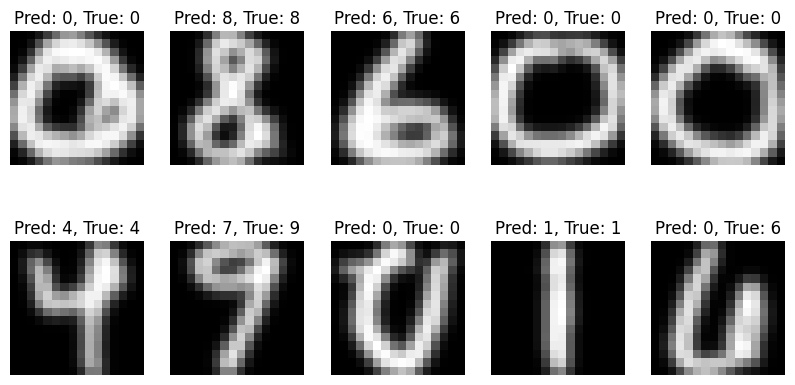

In [129]:
z_test = np.dot(X_test, W) + b
y_pred_test = softmax(z_test)
predictions = np.argmax(y_pred_test, axis=1)
true_labels = np.argmax(y_test_onehot, axis=1)

accuracy = np.mean(predictions == true_labels)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# visualization
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test.iloc[i].values.reshape(16, 16), cmap='gray')
    ax.set_title(f"Pred: {predictions[i]}, True: {true_labels[i]}")
    ax.axis('off')
plt.show()

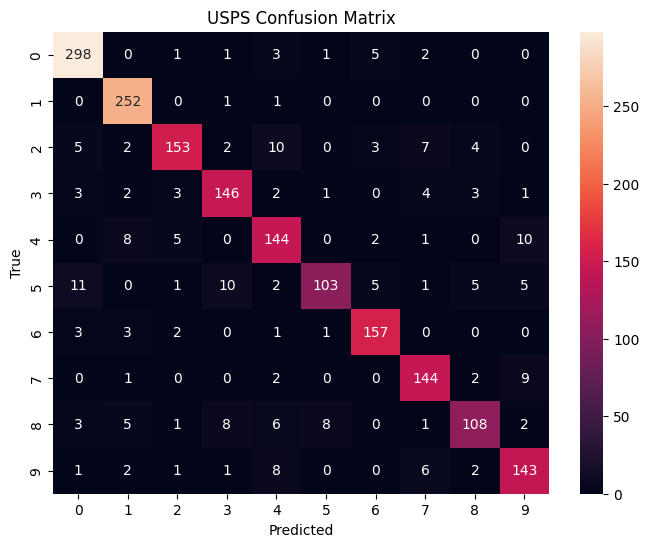

In [130]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("USPS Confusion Matrix")
plt.show()


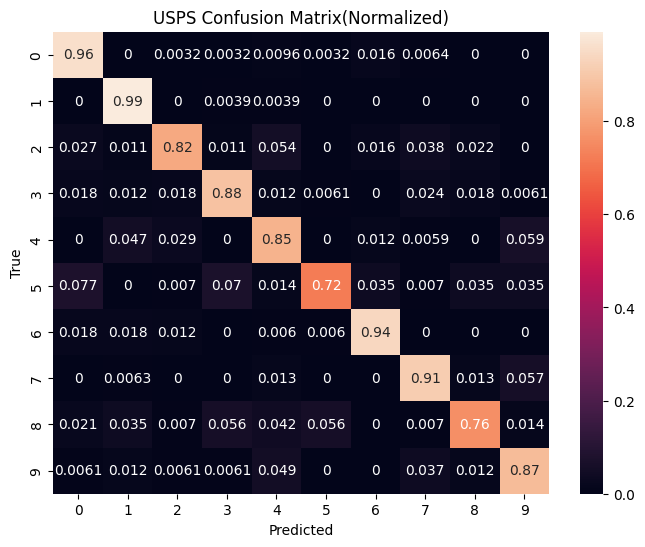

In [131]:
cm_norm = cm / cm.sum(axis=1, keepdims=True)
plt.figure(figsize=(8,6))
sns.heatmap(cm_norm, annot=True)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("USPS Confusion Matrix(Normalized)")
plt.show()

In [135]:
def tolerant_accuracy(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred)<=1)

print("Tolerant accuracy:", tolerant_accuracy(y_test, predictions))


Tolerant accuracy: 0.8989247311827957


In [136]:
misclassified = np.where(predictions != y_test)[0]
print(f"Number of misclassified samples: {len(misclassified)}")

Number of misclassified samples: 212
